1.라이브러리 불러오기

In [9]:
import os
import random
import fnmatch
import pickle

# data processing
import numpy as np
np.set_printoptions(formatter={'float_kind':lambda x: "%.4f" % x})

import pandas as pd
pd.set_option('display.width', 300)
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_colwidth', 200)

# tensorflow
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.models import Sequential  # V2 is tensorflow.keras.xxxx, V1 is keras.xxx
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

print( f'tf.__version__: {tf.__version__}' )
print( f'.keras.__version__: {tensorflow.keras.__version__}' )

# sklearn
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# imaging
import cv2
from imgaug import augmenters as img_aug
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image

tf.__version__: 1.14.0
.keras.__version__: 2.2.4-tf


2.데이터 불러오기

image_path: video/train_07049_090.png
steering_Angle: 90


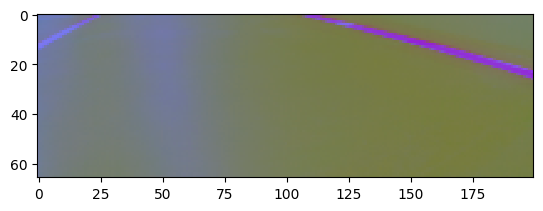

In [10]:
data_dir = r'video'
file_list = os.listdir(data_dir)
image_paths = []
steering_angles = []
pattern = "*.png"
for filename in file_list:
    if fnmatch.fnmatch(filename, pattern):
        image_paths.append(os.path.join(data_dir,filename))
        angle = int(filename[-7:-4]) 
        steering_angles.append(angle)

image_index = 20
plt.imshow(Image.open(image_paths[image_index]))
print("image_path: %s" % image_paths[image_index] )
print("steering_Angle: %d" % steering_angles[image_index] )
df = pd.DataFrame()
df['ImagePath'] = image_paths
df['Angle'] = steering_angles

3.조향각의 분포를 확인

(array([2310.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 25194.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        3460.0000]),
 array([45.0000, 48.6000, 52.2000, 55.8000, 59.4000, 63.0000, 66.6000,
        70.2000, 73.8000, 77.4000, 81.0000, 84.6000, 88.2000, 91.8000,
        95.4000, 99.0000, 102.6000, 106.2000, 109.8000, 113.4000, 117.0000,
        120.6000, 124.2000, 127.8000, 131.4000, 135.0000]),
 <a list of 25 Patch objects>)

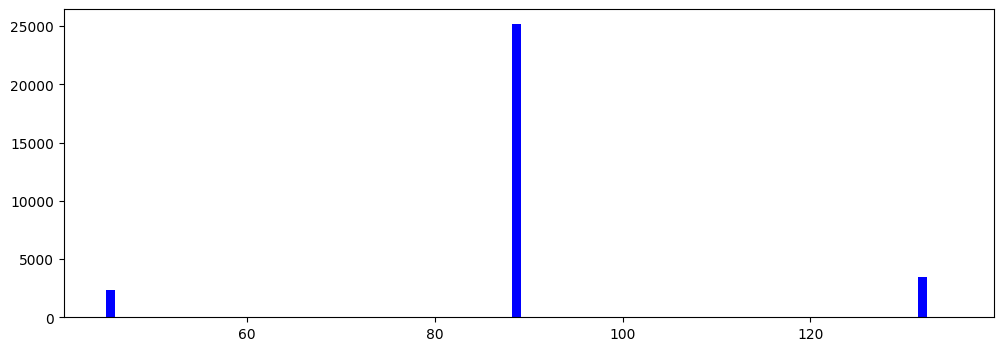

In [11]:
num_of_bins = 25 
hist, bins = np.histogram(df['Angle'], num_of_bins)

fig, axes = plt.subplots(1,1, figsize=(12,4))
axes.hist(df['Angle'], bins=num_of_bins, width=1, color='blue')

4. 학습데이터와 검증데이터를 분리

Training data: 24771
Validation data: 6193


Text(0.5, 1.0, 'Validation Data')

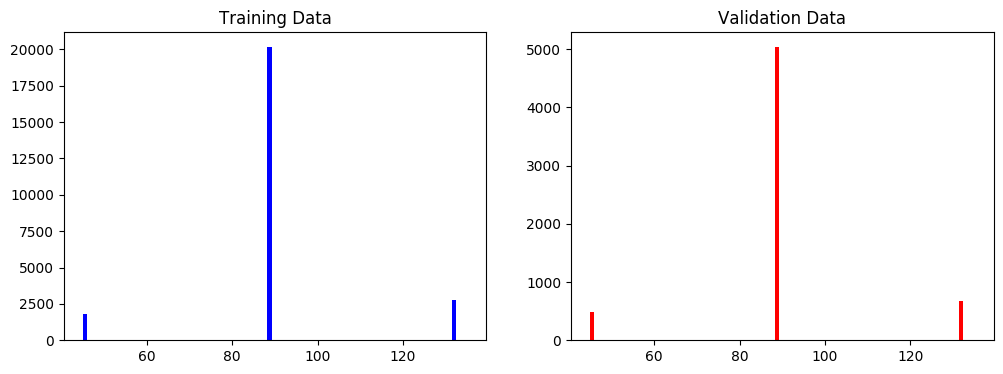

In [12]:
X_train, X_valid, y_train, y_valid = train_test_split( image_paths, steering_angles, test_size=0.2)
print("Training data: %d\nValidation data: %d" % (len(X_train), len(X_valid)))

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(y_train, bins=num_of_bins, width=1, color='blue')
axes[0].set_title('Training Data')
axes[1].hist(y_valid, bins=num_of_bins, width=1, color='red')
axes[1].set_title('Validation Data')

5. 이미지 읽어오기 및 정규화함수

Text(0.5, 1.0, 'processed')

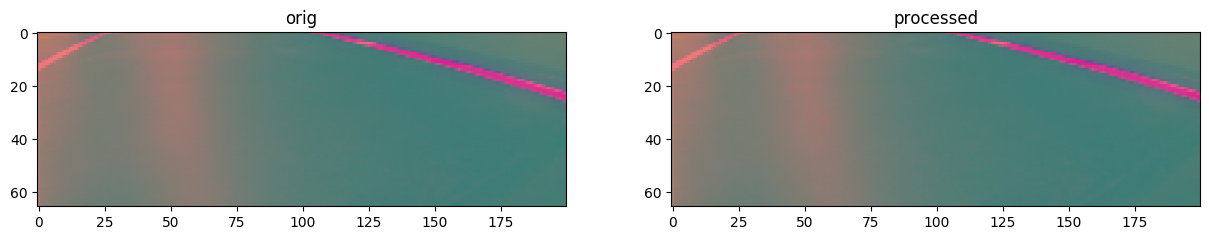

In [13]:
def my_imread(image_path):
    image = cv2.imread(image_path)
    return image

def img_preprocess(image):
    image = image / 255
    return image

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
image_orig = my_imread(image_paths[image_index])
image_processed = img_preprocess(image_orig)
axes[0].imshow(image_orig)
axes[0].set_title("orig")
axes[1].imshow(image_processed)
axes[1].set_title("processed")

6. nvidia 모델구성

In [14]:
def nvidia_model():
    model = Sequential(name='Nvidia_Model')

    model.add(Conv2D(24, (5, 5), strides=(2, 2), input_shape=(66, 200, 3), activation='elu')) 
    model.add(Conv2D(36, (5, 5), strides=(2, 2), activation='elu')) 
    model.add(Conv2D(48, (5, 5), strides=(2, 2), activation='elu')) 
    model.add(Conv2D(64, (3, 3), activation='elu')) 
    model.add(Dropout(0.2))
    model.add(Conv2D(64, (3, 3), activation='elu')) 

    model.add(Flatten())
    model.add(Dropout(0.2)) 
    model.add(Dense(100, activation='elu'))
    model.add(Dense(50, activation='elu'))
    model.add(Dense(10, activation='elu'))

    model.add(Dense(1))

    optimizer = Adam(lr=1e-3)
    model.compile(loss='mse', optimizer=optimizer)

    return model

model = nvidia_model()
print(model.summary())

Model: "Nvidia_Model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_5 (Conv2D)            (None, 31, 98, 24)        1824      
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 14, 47, 36)        21636     
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 5, 22, 48)         43248     
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 3, 20, 64)         27712     
_________________________________________________________________
dropout_2 (Dropout)          (None, 3, 20, 64)         0         
_________________________________________________________________
conv2d_9 (Conv2D)            (None, 1, 18, 64)         36928     
_________________________________________________________________
flatten_1 (Flatten)          (None, 1152)             

7. 학습데이터 생성

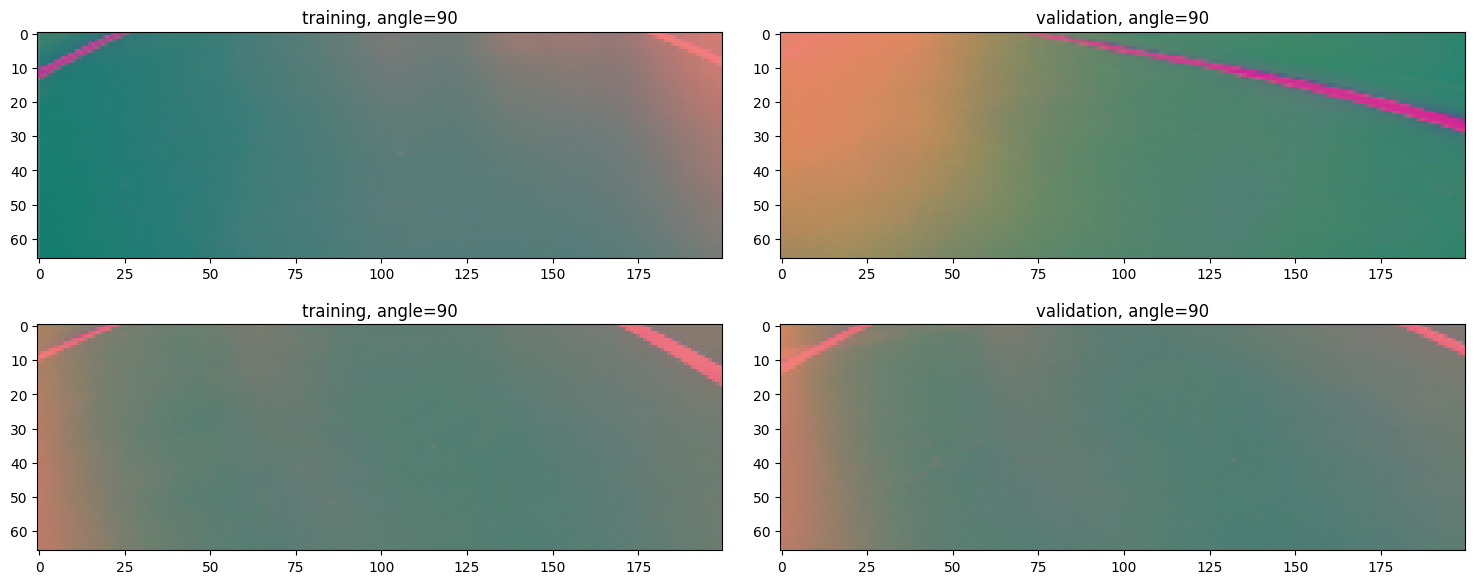

In [17]:
def image_data_generator(image_paths, steering_angles, batch_size):
    while True:
        batch_images = []
        batch_steering_angles = []
        
        for i in range(batch_size):
            random_index = random.randint(0, len(image_paths) - 1)
            image_path = image_paths[random_index]
            
            # 이미지 로드
            image = my_imread(image_paths[random_index])
            
            # [수정된 부분] 이미지가 제대로 로드되지 않았을 경우(None) 예외 처리
            if image is None:
#                 print(f"Warning: Failed to load image at {image_path}. Skipping...")
                continue  # 이 이미지는 건너뛰고 다음 반복으로 넘어감
            
            steering_angle = steering_angles[random_index]
            
            # 전처리 수행
            try:
                image = img_preprocess(image)
            except Exception as e:
#                 print(f"Error processing image {image_path}: {e}")
                continue

            batch_images.append(image)
            batch_steering_angles.append(steering_angle)
            
        yield( np.asarray(batch_images), np.asarray(batch_steering_angles))

ncol = 2
nrow = 2

X_train_batch, y_train_batch = next(image_data_generator(X_train, y_train, nrow))
X_valid_batch, y_valid_batch = next(image_data_generator(X_valid, y_valid, nrow))

fig, axes = plt.subplots(nrow, ncol, figsize=(15, 6))
fig.tight_layout()

for i in range(nrow):
    axes[i][0].imshow(X_train_batch[i])
    axes[i][0].set_title("training, angle=%s" % y_train_batch[i])
    axes[i][1].imshow(X_valid_batch[i])
    axes[i][1].set_title("validation, angle=%s" % y_valid_batch[i])

8.모델 학습(5~10분가량 소요)

In [18]:
model_output_dir = r"./"

checkpoint_callback = tensorflow.keras.callbacks.ModelCheckpoint(filepath=os.path.join(model_output_dir,'lane_navigation_check.h5'), verbose=1, save_best_only=True)

history = model.fit_generator(image_data_generator( X_train, y_train, batch_size=100),
                              steps_per_epoch=300,
                              epochs=10,
                              validation_data = image_data_generator( X_valid, y_valid, batch_size=100),
                              validation_steps=200,
                              verbose=1,
                              shuffle=1,
                              callbacks=[checkpoint_callback])

model.save(os.path.join(model_output_dir,'lane_navigation_final.h5'))

history_path = os.path.join(model_output_dir,'history.pickle')
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f, pickle.HIGHEST_PROTOCOL)

Epoch 1/10


2025-11-22 12:50:22.299079: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA
2025-11-22 12:50:22.320404: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 3494400000 Hz
2025-11-22 12:50:22.321297: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x43dc22a0 executing computations on platform Host. Devices:
2025-11-22 12:50:22.321319: I tensorflow/compiler/xla/service/service.cc:175]   StreamExecutor device (0): <undefined>, <undefined>
2025-11-22 12:50:22.389478: W tensorflow/compiler/jit/mark_for_compilation_pass.cc:1412] (One-time warning): Not using XLA:CPU for cluster because envvar TF_XLA_FLAGS=--tf_xla_cpu_global_jit was not set.  If you want XLA:CPU, either set that envvar, or use experimental_jit_scope to enable XLA:CPU.  To confirm that XLA is active, pass --vmodule=xla_compilation_cache=1 (as a proper command-line flag, not via TF_XLA_FLAGS) or s

 33/300 [==>...........................] - ETA: 23s - loss: 2283.2573Warning: Failed to load image at video/train_25641_090.png. Skipping...


 59/300 [====>.........................] - ETA: 19s - loss: 1459.6830Warning: Failed to load image at video/train_25958_090.png. Skipping...


 86/300 [=======>......................] - ETA: 16s - loss: 1122.8035Warning: Failed to load image at video/train_25919_090.png. Skipping...


...

228/300 [=====================>........] - ETA: 4s - loss: 267.6248Warning: Failed to load image at video/train_25686_090.png. Skipping...


254/300 [========================>.....] - ETA: 2s - loss: 267.2421Warning: Failed to load image at video/train_25540_090.png. Skipping...


283/300 [===========================>..] - ETA: 0s - loss: 267.5692Warning: Failed to load image at video/train_26049_090.png. Skipping...


299/300 [============================>.] - ETA: 0s - loss: 268.0185Warning: Failed to load image at video/train_25733_090.png. Skipping...



Epoch 00010: val_loss did not improve from 261.71577
300/300 [==============================] - 23s 77ms/step - loss: 268.0067 - val_loss: 269.5535


9. 결과확인

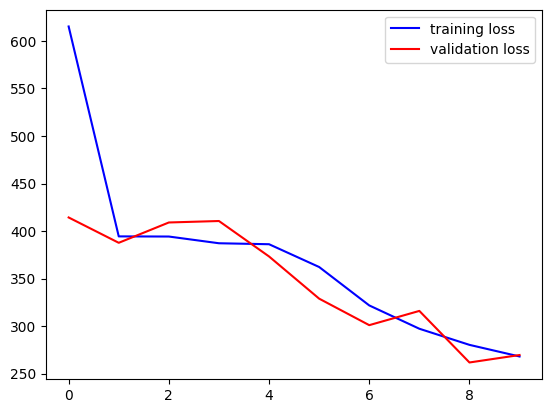

In [19]:
history.history

history_path = os.path.join(model_output_dir,'history.pickle')
with open(history_path, 'rb') as f:
    history = pickle.load(f)

history
plt.plot(history['loss'],color='blue')
plt.plot(history['val_loss'],color='red')
plt.legend(["training loss", "validation loss"])

10. 검증

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
mse       = 2.7e+02
r_squared = 15.42%



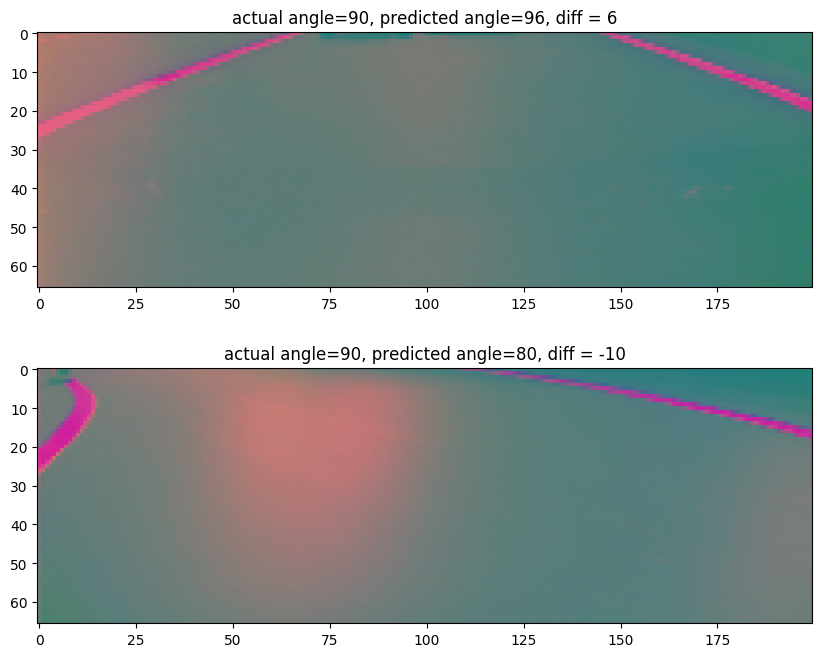

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

def summarize_prediction(Y_true, Y_pred):
    
    mse = mean_squared_error(Y_true, Y_pred)
    r_squared = r2_score(Y_true, Y_pred)
    
    print(f'mse       = {mse:.2}')
    print(f'r_squared = {r_squared:.2%}')
    print()
    
def predict_and_summarize(X, Y):
    model = load_model(f'{model_output_dir}/lane_navigation_check.h5')
    Y_pred = model.predict(X)
    summarize_prediction(Y, Y_pred)
    return Y_pred

n_tests = 100
X_test, y_test = next(image_data_generator(X_valid, y_valid, 100))

y_pred = predict_and_summarize(X_test, y_test)

n_tests_show = 2
fig, axes = plt.subplots(n_tests_show, 1, figsize=(10, 4 * n_tests_show))
for i in range(n_tests_show):
    axes[i].imshow(X_test[i])
    axes[i].set_title(f"actual angle={y_test[i]}, predicted angle={int(y_pred[i])}, diff = {int(y_pred[i])-y_test[i]}")

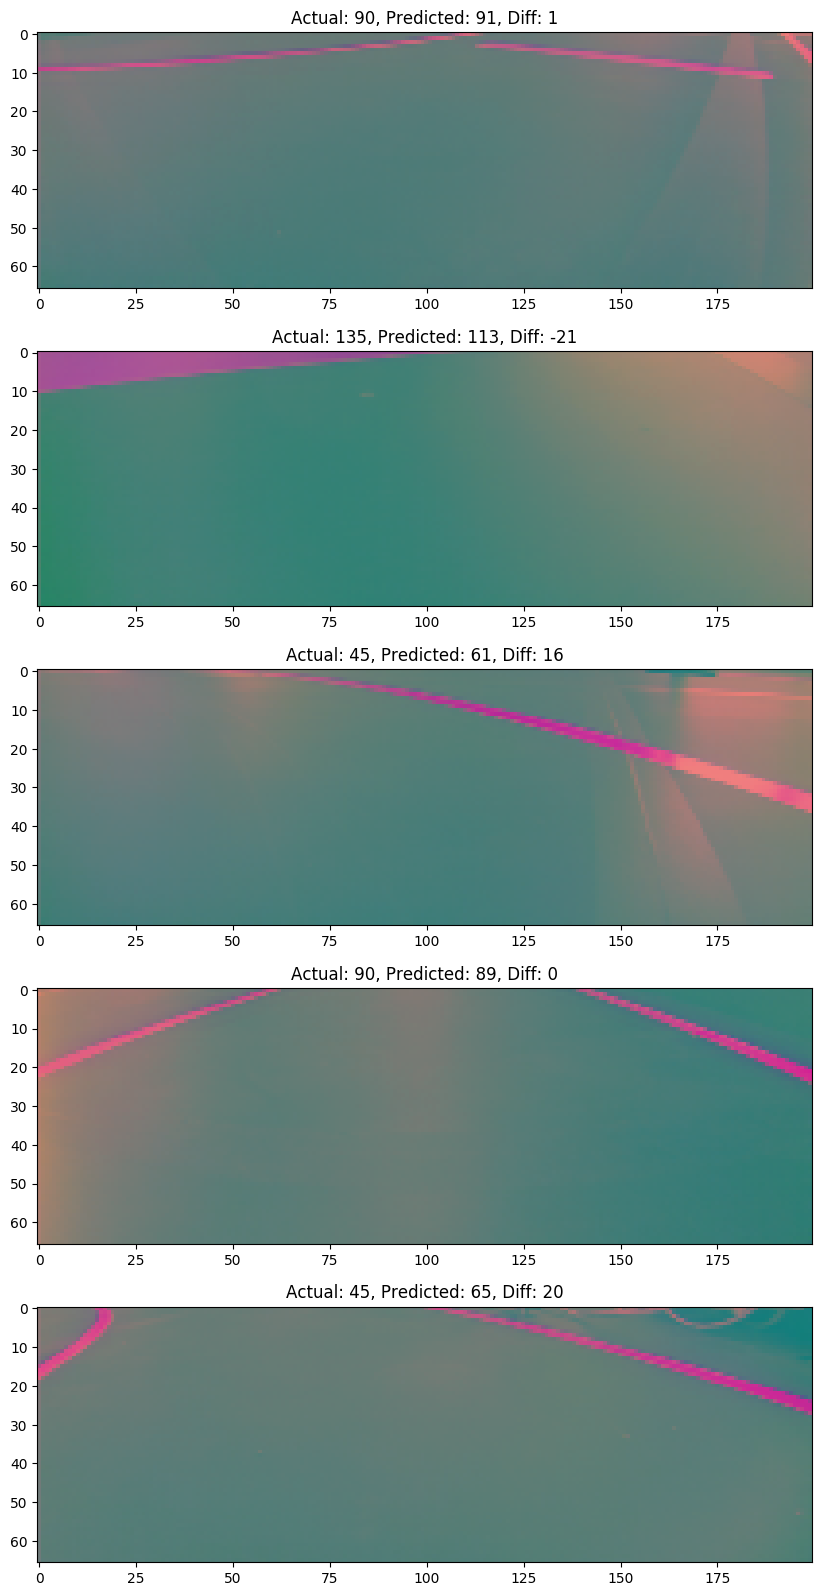

In [22]:
# 테스트 데이터 중 핸들을 많이 꺾어야 하는 상황(80도 이하 or 100도 이상)만 골라서 봅니다.
# X_valid, y_valid 데이터가 메모리에 있다고 가정합니다.

import numpy as np
import matplotlib.pyplot as plt

# 1. 커브 길 데이터 인덱스 찾기 (85도 이하 or 95도 이상인 경우만)
curve_indices = np.where((np.array(y_valid) < 80) | (np.array(y_valid) > 100))[0]

# 2. 랜덤하게 몇 개 뽑아서 예측해보기
if len(curve_indices) > 0:
    # 최대 5개만 뽑음
    sample_indices = np.random.choice(curve_indices, min(5, len(curve_indices)), replace=False)
    
    fig, axes = plt.subplots(len(sample_indices), 1, figsize=(10, 4 * len(sample_indices)))
    if len(sample_indices) == 1: axes = [axes] # 축이 하나일 때 리스트로 변환

    for i, idx in enumerate(sample_indices):
        image = my_imread(image_paths[idx]) # 원본 경로에서 다시 읽기 (또는 X_valid[idx] 사용)
        # 전처리가 필요하면 여기서 수행
        processed_image = img_preprocess(image)
        
        # 차원 추가 (1, 66, 200, 3) 형태로 변환해야 predict 가능
        input_image = np.expand_dims(processed_image, axis=0)
        
        pred = model.predict(input_image)[0][0]
        actual = steering_angles[idx] # 또는 y_valid[idx]
        
        axes[i].imshow(processed_image)
        axes[i].set_title(f"Actual: {actual}, Predicted: {int(pred)}, Diff: {int(pred - actual)}")
    plt.show()
else:
    print("검증 데이터에 커브길 데이터가 없습니다!")